# Inferência bayesiana de $(\Omega_m,\Omega_\Lambda)$ com as supernovas do Union2.1

**Objetivo.** Obter o posterior bidimensional em $(\Omega_m,\Omega_\Lambda)$ a
partir dos módulos de distância das 580 supernovas Ia da compilação Union2.1,
*sem impor planura*, usando a matriz de covariância com sistemáticas e tratando
explicitamente o zero-point das supernovas.

**Modelo.** FLRW com matéria, curvatura e constante cosmológica,

$$E^2(z)=\Omega_m(1+z)^3+\Omega_k(1+z)^2+\Omega_\Lambda,\qquad
\Omega_k=1-\Omega_m-\Omega_\Lambda .$$

**Método.** Verossimilhança gaussiana com a covariância $580\times580$ completa,
fatorada por Cholesky; zero-point $\mathcal M$ marginalizado analiticamente com
prior plano; prior próprio $0\le\Omega_m\le2$, $-1\le\Omega_\Lambda\le3$;
amostragem por Metropolis–Hastings com passeio aleatório de covariância adaptada
no aquecimento e congelada na fase retida; convergência avaliada por traces,
taxa de aceitação, split-$\hat R$, ESS/MCSE e pelo espectro de potências das
cadeias (Dunkley et al. 2005), sempre sem afinamento.

**Organização.** O código está no pacote `union21` (`cosmologia`, `analise`,
`diagnosticos`), com testes de aceitação em `tests/test_union21.py`. Este
notebook executa a análise e produz as figuras e os números reportados no
`README.md`.

In [1]:
import json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize

import union21
from union21 import FLRW, Verossimilhanca, carregar, construir_posterior
from union21 import ajustar_proposta, rodar_cadeias, pontos_iniciais
from union21 import diagnosticos as dg

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = RAIZ / "resultados" / "figuras"; FIG.mkdir(parents=True, exist_ok=True)
SEMENTE = 20240916

CORES = ["#0072B2", "#D55E00", "#009E73", "#8C56C0"]
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 180, "savefig.bbox": "tight",
                     "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#dddddd", "grid.linewidth": 0.6,
                     "legend.frameon": False, "lines.linewidth": 1.6,
                     "axes.prop_cycle": plt.cycler(color=CORES)})
print("union21", union21.__version__, "| numpy", np.__version__)

union21 1.0.0 | numpy 2.4.6


---
## 1. Dados e matriz de covariância

O release do Union2.1 fornece a tabela `SCPUnion2.1_mu_vs_z.txt` — nome da
supernova, redshift $z$, módulo de distância $\mu$, erro $\sigma_\mu$ e a
probabilidade de a galáxia hospedeira ter baixa massa — e a matriz de
covariância $580\times580$ do vetor $\mu$, aqui na versão **com sistemáticas**.

A leitura valida o que é usado adiante: número de supernovas, forma da matriz,
simetria, finitude e positividade definida (esta última verificada pela própria
fatoração de Cholesky, feita uma única vez na construção do objeto de dados).

A diagonal da covariância **já contém as variâncias** dos módulos de distância,
incluindo dispersão intrínseca e velocidades peculiares; nenhum termo de erro é
somado a ela. Na versão com sistemáticas a diagonal é maior que $\sigma_\mu^2$
tabelado e os elementos fora da diagonal são não nulos, refletindo erros de
calibração compartilhados entre supernovas de um mesmo levantamento.

In [2]:
dados = carregar(RAIZ / "dados")
print(dados.resumo())
print(f"log det C = {dados.log_det_cov:.3f}")

desvio = np.sqrt(np.diag(dados.cov))
print(f"sqrt(diag C) / sigma_mu: mínimo {np.min(desvio/dados.sigma):.3f}, "
      f"máximo {np.max(desvio/dados.sigma):.3f}")

Union2.1 [com sistemáticas]: N = 580 SNe, z ∈ [0.015, 1.414], elementos fora da diagonal não nulos: 99.8%, correlação máxima: 0.421
log det C = -1838.209
sqrt(diag C) / sigma_mu: mínimo 1.003, máximo 1.391


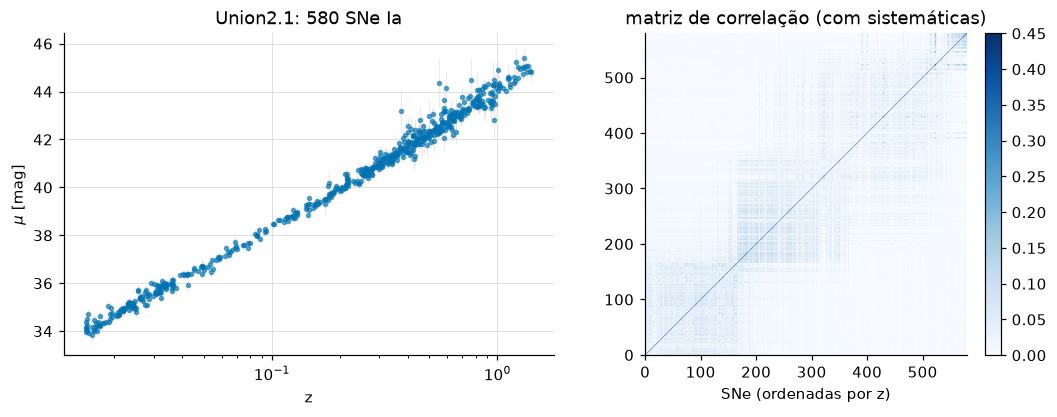

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8),
                         gridspec_kw=dict(width_ratios=[1.35, 1]))
axes[0].errorbar(dados.z, dados.mu, yerr=desvio, fmt="o", ms=2.6, lw=0.7,
                 alpha=0.6, color=CORES[0], ecolor="#dddddd")
axes[0].set_xscale("log"); axes[0].set_xlabel("z"); axes[0].set_ylabel(r"$\mu$ [mag]")
axes[0].set_title(f"Union2.1: {dados.n} SNe Ia")

ordem = np.argsort(dados.z)                       # ordena por z para ver a estrutura
corr = dados.cov / np.outer(desvio, desvio)
im = axes[1].imshow(corr[np.ix_(ordem, ordem)], cmap="Blues", vmin=0, vmax=0.45,
                    origin="lower")
axes[1].grid(False); axes[1].set_xlabel("SNe (ordenadas por z)")
axes[1].set_title("matriz de correlação (com sistemáticas)")
fig.colorbar(im, ax=axes[1], fraction=0.046)
fig.savefig(FIG / "dados.png"); plt.show()

---
## 2. Cosmologia de fundo

$$\chi(z)=c\!\int_0^z\!\frac{dz'}{H(z')},\qquad
D_M=S_K[\chi]=\begin{cases}
\dfrac{c/H_0}{\sqrt{\Omega_k}}\sinh\!\Big(\sqrt{\Omega_k}\dfrac{H_0\chi}{c}\Big), & \Omega_k>0,\\[2mm]
\chi, & \Omega_k=0,\\[2mm]
\dfrac{c/H_0}{\sqrt{|\Omega_k|}}\sin\!\Big(\sqrt{|\Omega_k|}\dfrac{H_0\chi}{c}\Big), & \Omega_k<0,
\end{cases}$$

$$D_A=\frac{D_M}{1+z},\qquad D_L=(1+z)D_M,\qquad
\mu=5\log_{10}\!\big(D_L/\mathrm{Mpc}\big)+25 .$$

A integral de $\chi$ é avaliada por quadratura de Gauss–Legendre de ordem fixa,
vetorizada em $z$: o integrando $1/E(z)$ é suave, 16 nós bastam para erro
relativo da ordem de $10^{-9}$ (verificado contra `scipy.integrate.quad`), e as
580 supernovas são calculadas em uma única chamada — condição para avaliar a
verossimilhança $10^5$ vezes.

Regiões do espaço de parâmetros em que $E^2(z)\le 0$ para algum $z$ do intervalo
dos dados correspondem a universos sem Big Bang, para os quais a integral de
distância não existe; o mesmo vale para $D_L\le0$ no caso fechado além do
antípoda. Nesses pontos as funções devolvem `nan` e o posterior é $-\infty$, ou
seja, o ponto é rejeitado. A verificação de $E^2>0$ é feita em uma grade densa,
e não apenas nos nós da quadratura, porque $E^2$ pode ser negativo entre dois nós.

In [4]:
c = FLRW(70, 0.3, 0.7)
z = np.linspace(0.01, 1.5, 40)
zl = np.array([1e-4, 1e-3])
zq = 1.0
ref_quad = quad(lambda zz: 1/float(np.atleast_1d(c.E(zz))[0]), 0, zq, epsabs=1e-12)[0]*c.D_H

print("E(0) = 1                        :", np.isclose(float(np.atleast_1d(c.E(0.0))[0]), 1.0))
print("D_M = chi para Omega_k = 0      :", np.allclose(c.D_M(z), c.chi(z)))
print("D_L = (1+z)^2 D_A (dualidade)   :", np.allclose(c.D_L(z), (1+z)**2*c.D_A(z)))
print("D_L -> lei de Hubble em z << 1  :", np.allclose(
    c.D_L(zl), union21.C_LUZ*zl/c.H0*(1 + 0.5*(1-c.q0)*zl), rtol=1e-6))
print(f"chi(1) vs quad                  : erro relativo {abs(float(c.chi(zq)[0])/ref_quad-1):.2e}")
print("universo sem Big Bang rejeitado :", not FLRW(70, 0.1, 2.5).valida(1.5))
print(f"idade do universo               : {float(c.idade(0.0)[0]):.2f} Gyr")

E(0) = 1                        : True
D_M = chi para Omega_k = 0      : True
D_L = (1+z)^2 D_A (dualidade)   : True
D_L -> lei de Hubble em z << 1  : True
chi(1) vs quad                  : erro relativo 0.00e+00
universo sem Big Bang rejeitado : True
idade do universo               : 13.47 Gyr


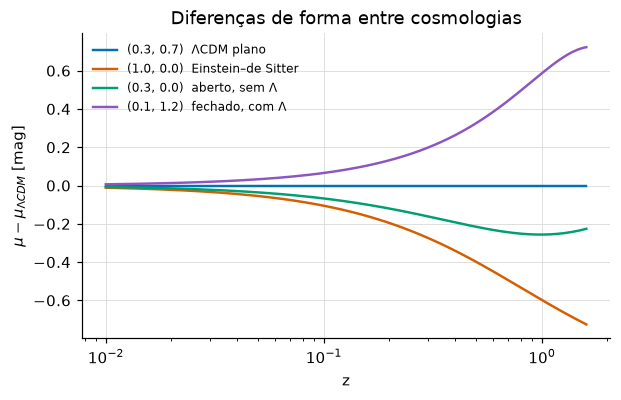

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
zz = np.geomspace(0.01, 1.6, 200)
ref = FLRW(70, 0.3, 0.7).mu(zz)
for i, (om, ol, lab) in enumerate([(0.3, 0.7, r"$(0.3,\,0.7)$  $\Lambda$CDM plano"),
                                   (1.0, 0.0, r"$(1.0,\,0.0)$  Einstein–de Sitter"),
                                   (0.3, 0.0, r"$(0.3,\,0.0)$  aberto, sem $\Lambda$"),
                                   (0.1, 1.2, r"$(0.1,\,1.2)$  fechado, com $\Lambda$")]):
    ax.plot(zz, FLRW(70, om, ol).mu(zz) - ref, color=CORES[i], label=lab)
ax.set_xscale("log"); ax.set_xlabel("z"); ax.set_ylabel(r"$\mu-\mu_{\Lambda CDM}$ [mag]")
ax.set_title("Diferenças de forma entre cosmologias"); ax.legend(fontsize=8)
fig.savefig(FIG / "formas.png"); plt.show()

As diferenças entre cosmologias são da ordem de décimos de magnitude e se
distribuem ao longo de todo o intervalo de redshift. Um deslocamento vertical
global da curva, por outro lado, é livre: é o zero-point tratado a seguir.

---
## 3. Verossimilhança e o zero-point $\mathcal{M}$

A verossimilhança é gaussiana no vetor de resíduos,

$$-2\ln\mathcal{L}=\Delta\mu^{T}C^{-1}\Delta\mu+\text{cte},\qquad
\Delta\mu=\mu_{\rm obs}-\mu_{\rm th}.$$

A matriz $C$ é fatorada por Cholesky uma única vez e cada avaliação usa
substituições triangulares (`cho_solve`); $C^{-1}$ nunca é formada, o que é mais
estável numericamente e reduz o custo por avaliação de $O(N^3)$ para $O(N^2)$.

### 3.1 Marginalização analítica

As supernovas Ia medem a forma de $\mu(z)$ a menos de um zero-point aditivo,

$$\mu_{\rm th}(z)=\mu_{\rm forma}(z;\Omega_m,\Omega_\Lambda)+\mathcal{M},
\qquad \mathcal{M}=M_B-5\log_{10}h+\text{cte},$$

que absorve a magnitude absoluta das SNe Ia e $H_0$. Com
$\Delta=\mu_{\rm obs}-\mu_{\rm forma}$ e $\mathbf 1=(1,\dots,1)^T$,

$$\chi^2(\mathcal{M})=A-2\mathcal{M}B+\mathcal{M}^2D,\qquad
A=\Delta^TC^{-1}\Delta,\quad B=\Delta^TC^{-1}\mathbf 1,\quad
D=\mathbf 1^TC^{-1}\mathbf 1 .$$

Adotando prior plano para $\mathcal{M}$, a integral é gaussiana:

$$\mathcal{L}=\int e^{-\chi^2(\mathcal M)/2}\,d\mathcal M=
\sqrt{\frac{2\pi}{D}}\;\exp\!\Big[-\frac{1}{2}\Big(A-\frac{B^2}{D}\Big)\Big]
\;\Longrightarrow\;
\chi^2_{\rm marg}=A-\frac{B^2}{D}+\ln\frac{D}{2\pi},$$

expressão de Goliath et al. (2001) e do Apêndice C de Amanullah et al. (2010).

**Justificativa da escolha.** Fixar $\mathcal{M}$ em um valor arbitrário equivale
a impor um prior delta sobre $M_B$ e $H_0$ e desloca os contornos (§3.3).
Perfilar em $\mathcal{M}$ fornece $A-B^2/D$ e coincide com a marginalização a
menos de uma constante aditiva apenas porque $D$ não depende dos parâmetros
cosmológicos; em geral maximizar não é integrar. Amostrar $\mathcal{M}$ como
terceiro parâmetro produziria o mesmo posterior bidimensional, já que o modelo é
linear em $\mathcal{M}$ e o prior é plano, ao custo de uma dimensão adicional na
cadeia. A marginalização analítica é, portanto, exata e a mais econômica.

O prior plano em $\mathcal{M}$ é impróprio. Isso é adequado para estimação de
parâmetros, em que a constante de normalização se cancela, mas não permitiria
calcular a evidência bayesiana; para comparação de modelos seria necessário
adotar limites finitos e declará-los.

Como $D$ e $C^{-1}\mathbf 1$ não dependem dos parâmetros, são pré-calculados, e
cada avaliação da verossimilhança custa um único `cho_solve`.

In [6]:
veros = Verossimilhanca(dados, H0_fiducial=70.0)
om, ol = 0.3, 0.7

t0 = time.time()
for _ in range(200): veros.log_like([om, ol])
print(f"custo por avaliação: {(time.time()-t0)/200*1e3:.2f} ms ({dados.n} SNe, C completa)")
print(f"zero-point ajustado em (0.3, 0.7): M = {veros.M_ajustado(om, ol):+.4f} "
      f"± {veros.sigma_M:.4f} mag")
print(f"chi2 perfilado = {veros.chi2_perfilado(om, ol):.1f} para {veros.dof} g.l. "
      f"(chi2/dof = {veros.chi2_perfilado(om, ol)/veros.dof:.3f})")

custo por avaliação: 0.70 ms (580 SNe, C completa)
zero-point ajustado em (0.3, 0.7): M = +0.0120 ± 0.0217 mag
chi2 perfilado = 545.1 para 577 g.l. (chi2/dof = 0.945)


### 3.2 Verificações da implementação

A marginalização analítica é comparada à integração numérica de
$\int e^{-\chi^2(\mathcal M)/2}d\mathcal M$, e verifica-se que o $\chi^2$
marginalizado é invariante tanto sob um deslocamento global de $\mu_{\rm obs}$
quanto sob mudança do $H_0$ fiducial — as duas transformações que $\mathcal{M}$
absorve por construção.

In [7]:
M0, sM = veros.M_ajustado(om, ol), veros.sigma_M
chi2_min = veros.chi2_perfilado(om, ol)
integral, _ = quad(lambda M: np.exp(-0.5*(veros.chi2_com_M(om, ol, M) - chi2_min)),
                   M0 - 40*sM, M0 + 40*sM, limit=400)
print(f"chi2 marginalizado, analítico : {veros.chi2(om, ol):.8f}")
print(f"chi2 marginalizado, numérico  : {chi2_min - 2*np.log(integral):.8f}")

deslocado = type(dados)(nome=dados.nome, z=dados.z, mu=dados.mu + 0.37,
                        sigma=dados.sigma, cov=dados.cov)
print("invariante sob mu -> mu + 0.37 mag:",
      np.isclose(veros.chi2(om, ol), Verossimilhanca(deslocado).chi2(om, ol)))
print("invariante sob H0 fiducial 70 -> 55:",
      np.isclose(veros.chi2(om, ol), Verossimilhanca(dados, 55).chi2(om, ol)))

chi2 marginalizado, analítico : 550.94993824
chi2 marginalizado, numérico  : 550.94993824
invariante sob mu -> mu + 0.37 mag: True
invariante sob H0 fiducial 70 -> 55: True


### 3.3 Efeito de fixar o zero-point

A figura abaixo mostra o perfil de $\Delta\chi^2$ ao longo da família plana com o
zero-point ajustado e com ele deslocado de $\pm0{,}10$ mag. Um erro dessa ordem
no zero-point desloca o mínimo em $\Omega_m$ muito além da incerteza estatística,
o que justifica trata-lo como parâmetro de incômodo em vez de fixá-lo.

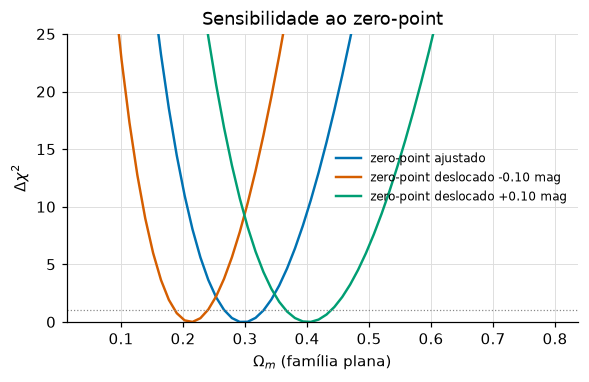

In [8]:
oms = np.linspace(0.05, 0.8, 60)
fig, ax = plt.subplots(figsize=(6.0, 3.4))
for i, dM in enumerate([0.0, -0.10, +0.10]):
    perfil = np.array([veros.chi2_com_M(o, 1-o, M0 + dM) for o in oms])
    ax.plot(oms, perfil - perfil.min(), color=CORES[i],
            label="zero-point ajustado" if dM == 0 else f"zero-point deslocado {dM:+.2f} mag")
ax.axhline(1.0, color="#888888", lw=0.8, ls=":")
ax.set_xlabel(r"$\Omega_m$ (família plana)"); ax.set_ylabel(r"$\Delta\chi^2$")
ax.set_ylim(0, 25); ax.legend(fontsize=8)
ax.set_title("Sensibilidade ao zero-point")
fig.savefig(FIG / "zero_point.png"); plt.show()

---
## 4. Prior e posterior

Prior plano e próprio na caixa $0\le\Omega_m\le2$ e $-1\le\Omega_\Lambda\le3$.
Fora dela, ou em pontos cuja cosmologia é inválida, o posterior é $-\infty$. O
prior é avaliado antes da verossimilhança, de modo que pontos fora da caixa não
consomem uma avaliação da forma quadrática.

In [9]:
log_post = construir_posterior(veros)
print(f"log posterior em (0.3, 0.7)  : {log_post([0.3, 0.7]):.2f}")
print(f"log posterior em (2.5, 0.7)  : {log_post([2.5, 0.7])}   (fora do prior)")
print(f"log posterior em (0.1, 2.5)  : {log_post([0.1, 2.5])}   (sem Big Bang)")

log posterior em (0.3, 0.7)  : -277.55
log posterior em (2.5, 0.7)  : -inf   (fora do prior)
log posterior em (0.1, 2.5)  : -inf   (sem Big Bang)


---
## 5. Amostragem por Metropolis–Hastings

A proposta é um passeio aleatório gaussiano, $\theta'=\theta+Lz$ com
$LL^T=\Sigma_q$ e $z\sim\mathcal N(0,I)$, portanto simétrica: o quociente de
propostas cancela e a aceitação depende apenas da razão de densidades do alvo.
Toda a aritmética é feita em log-probabilidade, pois $e^{-\chi^2/2}$ com
$\chi^2\sim 5\times10^2$ é indistinguível de zero em ponto flutuante.

O posterior é fortemente degenerado ao longo da direção
$\Omega_\Lambda \sim 1{,}5\,\Omega_m$, de modo que uma proposta isotrópica teria
eficiência baixa. A covariância da proposta é estimada em um aquecimento curto e
escalada por $2{,}38^2/d$ (Roberts, Gelman & Gilks), sendo então **congelada**:
adaptação durante a fase retida quebraria a propriedade de Markov e a garantia de
distribuição invariante.

Quatro cadeias partem de pontos sorteados do prior, válidos e mutuamente
separados, o que permite comparar cadeias independentes em vez de julgar uma
única trajetória aparentemente estável. Em cada rejeição o estado atual é gravado
novamente; descartar as repetições alteraria as frequências amostradas.

In [10]:
rng = np.random.default_rng(SEMENTE)

theta_map = minimize(lambda t: -log_post(t), [0.3, 0.7], method="Nelder-Mead",
                     options={"xatol": 1e-6, "fatol": 1e-8}).x
print("máximo a posteriori:", np.round(theta_map, 4))

cov_prop, piloto = ajustar_proposta(log_post, theta_map, rng)
corr_prop = cov_prop[0, 1] / np.sqrt(cov_prop[0, 0]*cov_prop[1, 1])
print(f"aceitação no piloto: {piloto.taxa_aceitacao:.3f}")
print("covariância congelada da proposta:\n", np.round(cov_prop, 5))
print(f"correlação da proposta: {corr_prop:.3f}")

máximo a posteriori: [0.2913 0.6964]
aceitação no piloto: 0.453
covariância congelada da proposta:
 [[0.03247 0.04653]
 [0.04653 0.09729]]
correlação da proposta: 0.828


In [11]:
N_PASSOS, N_WARMUP, N_CADEIAS = 25_000, 3_000, 4

inicios = pontos_iniciais(log_post, N_CADEIAS, semente=SEMENTE + 1)
print("pontos iniciais:", np.round(np.array(inicios), 3).tolist())

t0 = time.time()
cadeias = rodar_cadeias(log_post, inicios, N_PASSOS, cov_prop, semente=SEMENTE)
print(f"{N_CADEIAS} cadeias × {N_PASSOS} passos em {time.time()-t0:.0f} s")
print("taxas de aceitação:", [round(c.taxa_aceitacao, 3) for c in cadeias])

bruto  = np.stack([c.amostras for c in cadeias])
retido = np.stack([c.amostras[N_WARMUP:] for c in cadeias])   # sem afinamento
plana  = retido.reshape(-1, 2)
print("amostras retidas:", plana.shape)

pontos iniciais: [[1.75, -0.404], [1.017, -0.41], [0.1, -0.684], [0.385, 0.741]]
4 cadeias × 25000 passos em 59 s
taxas de aceitação: [0.385, 0.388, 0.385, 0.386]
amostras retidas: (88000, 2)


---
## 6. Convergência

Nenhum diagnóstico isolado demonstra convergência: cadeias podem parecer
estacionárias e ainda assim não ter explorado o alvo. Reporta-se, por isso, o
conjunto: traces e taxa de aceitação, split-$\hat R$, tempo de autocorrelação
integrado com ESS e MCSE, e o espectro de potências das cadeias. Todos os
diagnósticos usam as cadeias retidas sem afinamento.

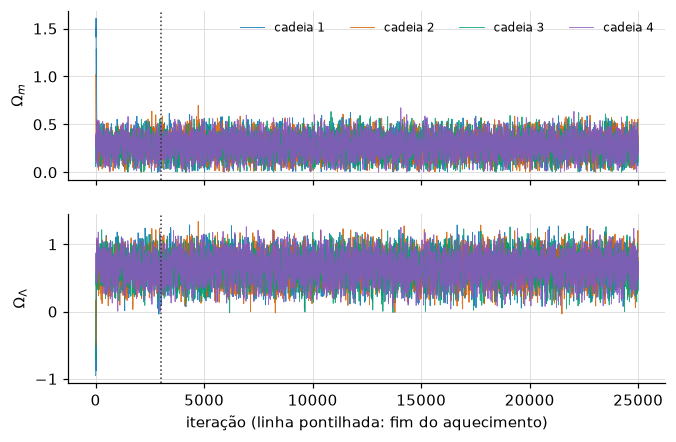

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(7.0, 4.4), sharex=True)
for i, nome in enumerate([r"$\Omega_m$", r"$\Omega_\Lambda$"]):
    for k in range(N_CADEIAS):
        axes[i].plot(np.arange(0, bruto.shape[1], 5), bruto[k, ::5, i], lw=0.6,
                     alpha=0.85, color=CORES[k], label=f"cadeia {k+1}" if i == 0 else None)
    axes[i].axvline(N_WARMUP, color="#333333", ls=":", lw=1.0)
    axes[i].set_ylabel(nome)
axes[0].legend(ncol=4, fontsize=8, loc="upper right")
axes[-1].set_xlabel("iteração (linha pontilhada: fim do aquecimento)")
fig.savefig(FIG / "traces.png"); plt.show()

In [13]:
texto = dg.relatorio(retido, ["Omega_m", "Omega_Lambda"])
print(texto)
(RAIZ / "resultados" / "convergencia.txt").write_text(texto + "\n", encoding="utf-8")

Cadeias: 4 × 22000 passos retidos (sem thinning)

   parâmetro     média    desvio      MCSE  split-R̂       ESS       j*         r  situação
     Omega_m    0.2801    0.1133   0.00104    1.0003     11831      771   0.00038  ok
Omega_Lambda    0.6608    0.2110   0.00206    1.0005     10532      704   0.00042  ok

Critérios: split-R̂ < 1.01 (guia, não garantia); j* > 20 e r < 0.01 (Dunkley et al. 2005).


406

O split-$\hat R$ compara a variação entre cadeias com a variação interna,
partindo cada cadeia ao meio para detectar também tendências dentro de uma mesma
cadeia; valores abaixo de $1{,}01$ são o critério usual. O ESS,
$N_{\rm eff}=N/\tau_{\rm int}$, mede a informação efetivamente contida nas
cadeias correlacionadas, e o MCSE, $s_x/\sqrt{N_{\rm eff}}$, quantifica o erro de
Monte Carlo das médias reportadas: ele deve ser muito menor que o desvio-padrão
posterior, caso contrário o valor central reportado seria dominado por ruído do
amostrador.

O diagnóstico espectral ajusta $P(k)=P_0/[1+(k/k_\star)^\alpha]$ ao periodograma
de cada cadeia centrada, com $k_j=2\pi j/N$. Como as ordenadas do periodograma
são exponencialmente distribuídas em torno do espectro verdadeiro, o ajuste é
feito por máxima verossimilhança, minimizando
$\sum_j[\ln P(k_j)+\hat P_j/P(k_j)]$, e não por mínimos quadrados em $\log P$. Os
critérios são $j_\star>20$, indicando que o platô branco de baixa frequência está
resolvido, e $r=P_0/(Ns_x^2)<0{,}01$, indicando média suficientemente precisa.

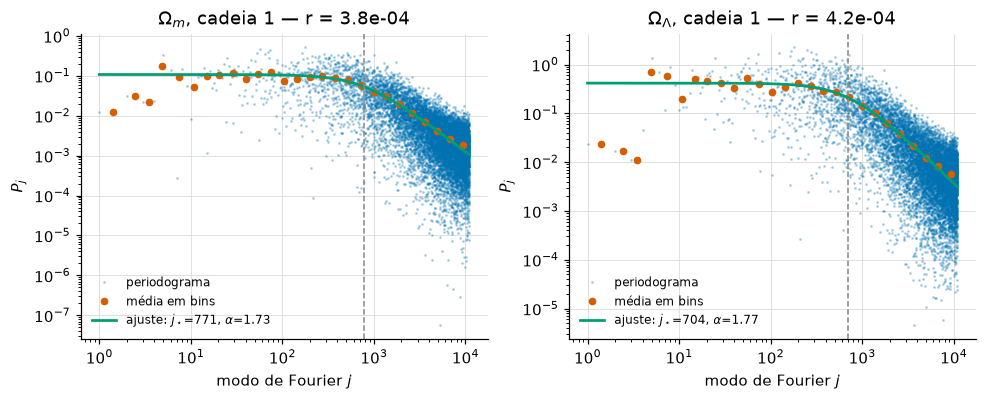

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
for i, nome in enumerate([r"$\Omega_m$", r"$\Omega_\Lambda$"]):
    x = retido[0, :, i]
    j, k, P = dg.espectro(x)
    aj = dg.ajustar_dunkley(x)
    axes[i].loglog(j, P, ".", ms=1.8, alpha=0.25, color=CORES[0], label="periodograma")
    bordas = np.unique(np.geomspace(1, j.max(), 30).astype(int))
    centros = [np.sqrt(a*b) for a, b in zip(bordas[:-1], bordas[1:])]
    medias = [P[(j >= a) & (j < b)].mean() for a, b in zip(bordas[:-1], bordas[1:])]
    axes[i].loglog(centros, medias, "o", ms=4, color=CORES[1], label="média em bins")
    axes[i].loglog(j, dg.modelo_dunkley(k, aj.P0, aj.k_estrela, aj.alpha), lw=1.8,
                   color=CORES[2],
                   label=rf"ajuste: $j_\star$={aj.j_estrela:.0f}, $\alpha$={aj.alpha:.2f}")
    axes[i].axvline(aj.j_estrela, color="#888888", ls="--", lw=1.0)
    axes[i].set_xlabel("modo de Fourier $j$"); axes[i].set_ylabel("$P_j$")
    axes[i].set_title(f"{nome}, cadeia 1 — r = {aj.r:.1e}")
    axes[i].legend(fontsize=8, loc="lower left")
fig.savefig(FIG / "dunkley.png"); plt.show()

---
## 7. Resultados

As regiões de credibilidade são obtidas do histograma bidimensional suavizado das
amostras: as densidades são ordenadas de forma decrescente e acumuladas, e os
níveis correspondentes a 68% e 95% da massa posterior definem os contornos.

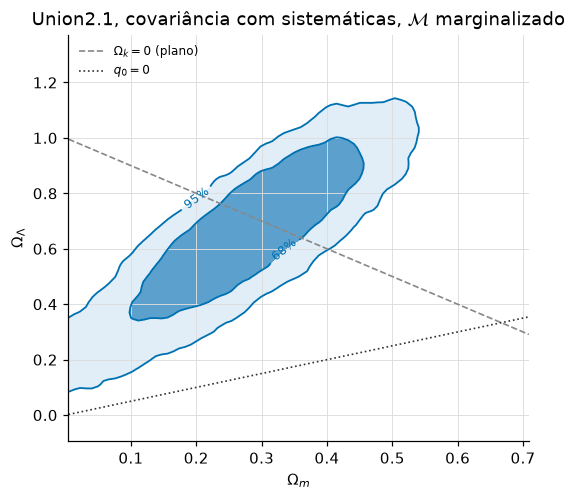

In [15]:
def contornos(x, y, ax, bins=80, suavizar=1.1, cor=CORES[0]):
    H, xe, ye = np.histogram2d(x, y, bins=bins, density=True)
    H = gaussian_filter(H, suavizar).T
    ordenado = np.sort(H.ravel())[::-1]
    acum = np.cumsum(ordenado) / ordenado.sum()
    niveis = sorted(float(ordenado[np.searchsorted(acum, p)]) for p in (0.95, 0.68))
    xc, yc = 0.5*(xe[1:]+xe[:-1]), 0.5*(ye[1:]+ye[:-1])
    ax.contourf(xc, yc, H, levels=niveis + [H.max()*1.01], cmap="Blues", alpha=0.85)
    cs = ax.contour(xc, yc, H, levels=niveis, colors=cor, linewidths=1.2)
    ax.clabel(cs, fontsize=8, fmt={niveis[0]: "95%", niveis[-1]: "68%"})

fig, ax = plt.subplots(figsize=(5.4, 4.8))
contornos(plana[:, 0], plana[:, 1], ax)
lim = ax.get_xlim(); xs = np.linspace(*lim, 50)
ax.plot(xs, 1 - xs, "--", lw=1.1, color="#888888", label=r"$\Omega_k=0$ (plano)")
ax.plot(xs, 0.5*xs, ":", lw=1.1, color="#333333", label=r"$q_0=0$")
ax.set_xlim(*lim); ax.set_xlabel(r"$\Omega_m$"); ax.set_ylabel(r"$\Omega_\Lambda$")
ax.set_title("Union2.1, covariância com sistemáticas, $\\mathcal{M}$ marginalizado")
ax.legend(fontsize=8, loc="upper left")
fig.savefig(FIG / "contornos.png"); plt.show()

      Omega_m:  0.283  +0.112 -0.120 (68%)   [ 0.052,  0.497] (95%)
 Omega_Lambda:  0.669  +0.203 -0.225 (68%)   [ 0.230,  1.052] (95%)
      Omega_k:  0.047  +0.332 -0.304 (68%)   [-0.518,  0.696] (95%)
           q0: -0.529  +0.178 -0.157 (68%)   [-0.831, -0.182] (95%)


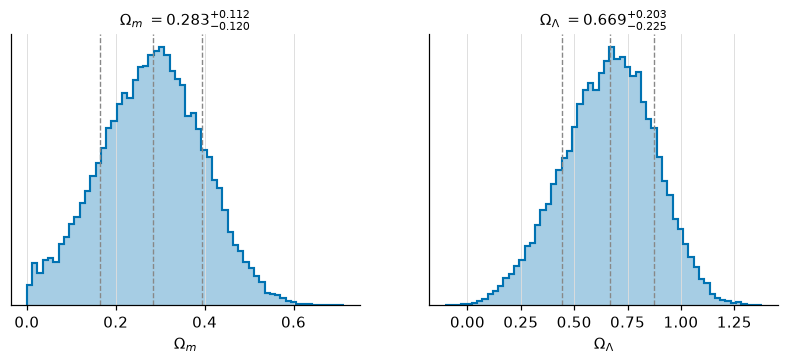


P(q0 < 0 | dados) = 0.99936
correlação entre Omega_m e Omega_Lambda = 0.840
chi2 mínimo = 545.1 para 577 g.l. (chi2/dof = 0.945)


1446

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.2))
resultados = {"covariancia": dados.rotulo, "n_sn": dados.n, "semente": SEMENTE,
              "n_cadeias": N_CADEIAS, "n_passos": N_PASSOS, "n_warmup": N_WARMUP,
              "aceitacao": [round(c.taxa_aceitacao, 4) for c in cadeias]}

def resumir(x, nome, ax=None, rotulo=None):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    resultados[nome] = {"mediana": float(q50), "mais": float(q84-q50),
                        "menos": float(q50-q16), "media": float(x.mean()),
                        "desvio": float(x.std(ddof=1)),
                        "q2.5": float(np.percentile(x, 2.5)),
                        "q97.5": float(np.percentile(x, 97.5))}
    print(f"{nome:>13}: {q50:6.3f}  +{q84-q50:.3f} -{q50-q16:.3f} (68%)   "
          f"[{np.percentile(x, 2.5):6.3f}, {np.percentile(x, 97.5):6.3f}] (95%)")
    if ax is not None:
        ax.hist(x, bins=60, density=True, color=CORES[0], alpha=0.35)
        ax.hist(x, bins=60, density=True, histtype="step", color=CORES[0], lw=1.4)
        for q in (q16, q50, q84): ax.axvline(q, color="#888888", ls="--", lw=0.9)
        ax.set_yticks([]); ax.set_xlabel(rotulo)
        ax.set_title(f"{rotulo} $= {q50:.3f}^{{+{q84-q50:.3f}}}_{{-{q50-q16:.3f}}}$",
                     fontsize=10)

om_s, ol_s = plana[:, 0], plana[:, 1]
resumir(om_s, "Omega_m", axes[0], r"$\Omega_m$")
resumir(ol_s, "Omega_Lambda", axes[1], r"$\Omega_\Lambda$")
resumir(1 - om_s - ol_s, "Omega_k")
resumir(0.5*om_s - ol_s, "q0")
fig.savefig(FIG / "marginais.png"); plt.show()

resultados["P(q0<0)"] = float(np.mean(0.5*om_s - ol_s < 0))
resultados["correlacao"] = float(np.corrcoef(om_s, ol_s)[0, 1])
resultados["chi2_min"] = float(veros.chi2_perfilado(*theta_map))
resultados["dof"] = int(veros.dof)
resultados["MAP"] = [float(theta_map[0]), float(theta_map[1])]
resultados["M_ajustado"] = float(veros.M_ajustado(*theta_map))
print()
print(f"P(q0 < 0 | dados) = {resultados['P(q0<0)']:.5f}")
print(f"correlação entre Omega_m e Omega_Lambda = {resultados['correlacao']:.3f}")
print(f"chi2 mínimo = {resultados['chi2_min']:.1f} para {veros.dof} g.l. "
      f"(chi2/dof = {resultados['chi2_min']/veros.dof:.3f})")
(RAIZ / "resultados" / "resultados.json").write_text(json.dumps(resultados, indent=2))

$\Omega_k$ e $q_0=\Omega_m/2-\Omega_\Lambda$ são quantidades derivadas, obtidas
aplicando-se as respectivas funções às amostras retidas, sem nova amostragem. O
valor de $P(q_0<0\mid \text{dados})$ é a probabilidade posterior de expansão
acelerada hoje sob o modelo e o prior adotados. O intervalo de $\Omega_k$ é
consistente com um universo espacialmente plano, embora as supernovas sozinhas
não o vinculem com precisão, dada a degenerescência com $\Omega_m$ e
$\Omega_\Lambda$.

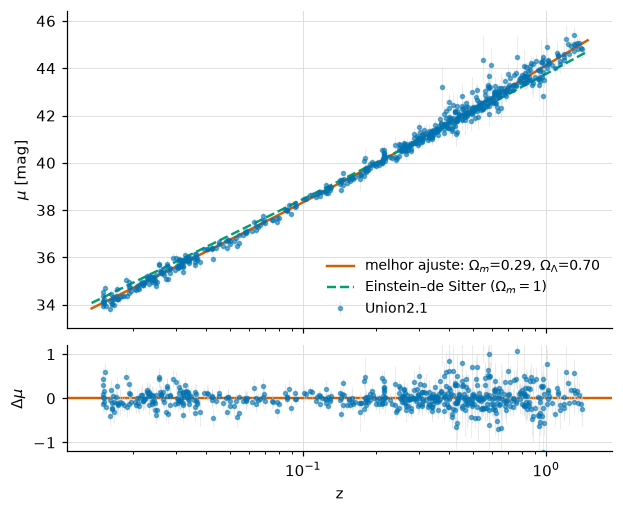

In [17]:
melhor, M_best = FLRW(70, *theta_map), veros.M_ajustado(*theta_map)
zz = np.geomspace(dados.z.min()*0.9, dados.z.max()*1.05, 200)
eds = FLRW(70, 1.0, 0.0)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(6.4, 5.2), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08))
ax.errorbar(dados.z, dados.mu, yerr=desvio, fmt="o", ms=2.6, lw=0.7, alpha=0.55,
            color=CORES[0], ecolor="#dddddd", label="Union2.1")
ax.plot(zz, melhor.mu(zz) + M_best, color=CORES[1],
        label=rf"melhor ajuste: $\Omega_m$={theta_map[0]:.2f}, $\Omega_\Lambda$={theta_map[1]:.2f}")
ax.plot(zz, eds.mu(zz) + veros.M_ajustado(1.0, 0.0), "--", color=CORES[2],
        label=r"Einstein–de Sitter ($\Omega_m=1$)")
ax.set_xscale("log"); ax.set_ylabel(r"$\mu$ [mag]"); ax.legend(fontsize=9, loc="lower right")
axr.axhline(0, color=CORES[1]); axr.set_ylim(-1.2, 1.2)
axr.errorbar(dados.z, dados.mu - (melhor.mu(dados.z) + M_best), yerr=desvio,
             fmt="o", ms=2.6, lw=0.7, alpha=0.55, color=CORES[0], ecolor="#dddddd")
axr.set_xlabel("z"); axr.set_ylabel(r"$\Delta\mu$")
fig.savefig(FIG / "hubble.png"); plt.show()

---
## 8. Escolhas de modelagem e limitações

1. **Zero-point.** $\mathcal{M}$ é marginalizado analiticamente com prior plano
   impróprio (§3.1). A escolha é exata para o modelo linear em $\mathcal{M}$ e
   torna o resultado independente do $H_0$ fiducial; em contrapartida, as
   supernovas sozinhas não vinculam $H_0$ nesta análise, e a evidência bayesiana
   não pode ser calculada sem antes tornar o prior próprio.
2. **Prior.** Plano em $0\le\Omega_m\le2$, $-1\le\Omega_\Lambda\le3$. Pontos com
   $E^2(z)\le0$ no intervalo dos dados ou com $D_L\le0$ são rejeitados. Priores
   planos não são invariantes por reparametrização: os resultados são
   condicionais a essa escolha.
3. **Covariância.** Usada como fornecida no release, incluindo sistemáticas. A
   diagonal já contém as variâncias e nenhum termo adicional de erro é somado.
4. **Radiação.** $\Omega_r=0$; a contribuição é desprezível para $z\le1{,}414$.
5. **Correções de padronização.** Os módulos de distância do arquivo já
   incorporam os parâmetros $\alpha$, $\beta$ e $\delta$ ajustados pelo SCP. A
   coluna de probabilidade de hospedeira de baixa massa é lida mas não utilizada:
   reajustar essas correções exigiria os dados de *stretch* e cor de cada
   supernova, ausentes deste arquivo.
6. **Amostrador.** Metropolis–Hastings com passeio aleatório e covariância
   congelada. Os diagnósticos da §6 atestam mistura adequada para o posterior
   unimodal deste problema, mas não excluiriam modos distantes não visitados.

### Reprodutibilidade

Semente `20240916`; cada cadeia recebe uma semente derivada por
`np.random.SeedSequence(semente).spawn(n)`, de modo que uma nova execução com a
mesma semente reproduz exatamente as cadeias. As figuras são gravadas em
`resultados/figuras/`, o relatório de convergência em
`resultados/convergencia.txt` e os vínculos em `resultados/resultados.json`.

### Referências

* Suzuki et al. (2012), ApJ 746, 85 — compilação Union2.1.
* Amanullah et al. (2010), ApJ 716, 712 — Apêndice C, parâmetros de incômodo lineares.
* Goliath et al. (2001), A&A 380, 6 — marginalização analítica do zero-point.
* Dunkley et al. (2005), MNRAS 356, 925 — diagnóstico espectral de convergência.
* Gelman & Rubin (1992), Statist. Sci. 7, 457 — $\hat R$.
* Roberts, Gelman & Gilks (1997), Ann. Appl. Probab. 7, 110 — escala ótima da proposta.
* Hogg (1999), astro-ph/9905116 — convenções de medidas de distância.